# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html
## Setup
Check the environment, import dependencies, and set paths.

In [1]:
import sys
print(sys.version)
print(sys.executable)
import importlib
print(importlib.util.find_spec("scbiot"))
import scbiot as scb


3.12.8 (main, Jan 14 2025, 22:49:14) [Clang 19.1.6 ]
/home/figo/software/python_libs/scbiot/.venv/bin/python
ModuleSpec(name='scbiot', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7766ddfb9730>, origin='/home/figo/software/python_libs/scbiot/src/scbiot/__init__.py', submodule_search_locations=['/home/figo/software/python_libs/scbiot/src/scbiot'])
scbiot version 1.1.7


/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import torch
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path(os.environ.get("SCBIOT_EXAMPLES_PATH", Path.cwd()))
print(dir)
parent_dir = dir.parent
print(parent_dir)


Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


## Load
Read the lung atlas dataset from disk.

In [3]:
adata_path = f"{dir}/inputs/panc8.h5ad"

adata = sc.read(
    adata_path,
    # backup_url="https://figshare.com/ndownloader/files/24539942",
)


In [4]:
adata.obs['tech'].value_counts()

tech
indrop        8569
smartseq2     2394
celseq2       2285
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

In [5]:
adata.obs['cell_type'] = adata.obs['celltype']
adata.obs['batch'] = adata.obs['tech']

## Preprocess
Create semi-supervised labels and compute PCA features. Here, we randomly select 20% of cells as truly labeled and assign the remaining cells the label Unknown. For custom datasets, you can instead label high-confidence cells by thresholding marker-gene module scores at the 80th percentile, then propagate these seed labels to the remaining cells with the supBIOT method.

In [6]:
import pandas as pd

def set_reference_batch_labels(
    adata,
    *,
    batch_key="batch",
    ref_batch="4",              # compare as string to handle mixed int/str batches
    label_key="cell_type",
    out_key="semi_cell_type",
    unlabeled_tag="Unknown",
):
    # normalize batch to string for robust matching (your obs['batch'] mixes ints/strings)
    b = adata.obs[batch_key].astype(str)
    is_ref = (b == str(ref_batch))

    # true labels as string; fill NA as Unknown
    true_lab = adata.obs[label_key].astype("string").fillna(unlabeled_tag)

    # categories: preserve existing category order if categorical, else sorted uniques
    if pd.api.types.is_categorical_dtype(adata.obs[label_key]):
        cats = list(adata.obs[label_key].cat.categories.astype(str))
    else:
        cats = sorted(pd.unique(true_lab.astype(str)))
    if unlabeled_tag not in cats:
        cats.append(unlabeled_tag)

    # assign: keep labels in ref batch, mask others
    semi = pd.Series(unlabeled_tag, index=adata.obs_names, dtype="string")
    semi.loc[is_ref] = true_lab.loc[is_ref].astype("string")
    adata.obs[out_key] = pd.Categorical(semi.astype(str), categories=cats)

    # quick sanity prints
    print(f"[semi labels] ref_batch={ref_batch} labeled={is_ref.sum()} / total={adata.n_obs}")
    print(adata.obs[out_key].value_counts().head(20))
    print("\n[per-batch labeled fraction]")
    tmp = pd.DataFrame({
        "batch": b,
        "is_labeled": adata.obs[out_key].astype(str).ne(unlabeled_tag),
    })
    print(tmp.groupby("batch")["is_labeled"].mean().sort_values(ascending=False).head(20))

# --- usage ---
set_reference_batch_labels(adata, batch_key="batch", ref_batch="indrop", label_key="cell_type", out_key="semi_cell_type")

[semi labels] ref_batch=indrop labeled=8569 / total=14890
semi_cell_type
Unknown               6321
beta                  2507
alpha                 2309
acinar                1152
ductal                 915
delta                  608
activated_stellate     294
gamma                  266
endothelial            235
quiescent_stellate     160
macrophage              55
mast                    39
epsilon                 16
schwann                 13
Name: count, dtype: int64

[per-batch labeled fraction]
batch
indrop        1.0
celseq        0.0
celseq2       0.0
fluidigmc1    0.0
smartseq2     0.0
Name: is_labeled, dtype: float64


In [7]:
# sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key='batch')
# sc.pp.scale(adata)
# sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

adata_pre = adata.copy()

## Integrate
Run supervised OT integration and infer labels with supBIOT.

In [8]:
adata, metrics = scb.ot.integrate(
    adata,
    obsm_key="X_pca",
    batch_key="batch",
    # prealign='coral',
    out_key="X_supbiot",
    label_key="semi_cell_type",
    unlabeled_category="Unknown",
    run_three_stage=True
)
print(metrics)


adata = scb.ot.supbiot(
    adata,
    label_key="semi_cell_type",
    unlabeled_category="Unknown",
    pred_label_key="pred_cell_type",
    pred_conf_key="pred_confidence",
    min_conf=0.0,
)


======== Stage1: supervised OT for label propagation ========
[baseline] KNN backend=FAISS-GPU mix=0.0444 strain=0.00000
[iter 01] mix=0.051 overlap0=0.943 strain=0.00065 floor~0.600 J=0.169 best_it=1
[iter 02] mix=0.060 overlap0=0.902 strain=0.00209 floor~0.607 J=0.175 best_it=2
[iter 03] mix=0.073 overlap0=0.864 strain=0.00458 floor~0.614 J=0.181 best_it=3
[iter 04] mix=0.092 overlap0=0.819 strain=0.00851 floor~0.621 J=0.183 best_it=4
[iter 05] mix=0.121 overlap0=0.773 strain=0.01367 floor~0.629 J=0.196 best_it=5
[iter 06] mix=0.165 overlap0=0.722 strain=0.01970 floor~0.636 J=0.222 best_it=6
[iter 07] mix=0.231 overlap0=0.660 strain=0.02702 floor~0.643 J=0.263 best_it=7
[iter 08] mix=0.318 overlap0=0.597 strain=0.03488 floor~0.650 J=0.325 best_it=8
[iter 09] mix=0.412 overlap0=0.534 strain=0.04153 floor~0.657 J=0.381 best_it=9
[iter 10] mix=0.464 overlap0=0.491 strain=0.04808 floor~0.664 J=0.405 best_it=10
[iter 11] mix=0.483 overlap0=0.458 strain=0.05413 floor~0.671 J=0.393 best_it=

In [9]:
adata

AnnData object with n_obs × n_vars = 14890 × 34363
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tech', 'replicate', 'assigned_cluster', 'celltype', 'dataset', 'ident', 'cell_type', 'batch', 'semi_cell_type', 'pred_cell_type', 'pred_confidence'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'X_name', 'hvg', 'log1p', 'pca', '_ot_alignment', '_supbiot'
    obsm: 'X_pca', 'X_supbiot'
    varm: 'PCs'
    layers: 'logcounts'

In [10]:
from sklearn.metrics import normalized_mutual_info_score

unlabeled_category = "Unknown"  # set to whatever you used

y_true = adata.obs["cell_type"]
y_pred = adata.obs["pred_cell_type"]
y_semi = adata.obs["semi_cell_type"]

# remove cells that have a semi_cell_type label (i.e., keep only unlabeled cells)
mask = (
    y_true.notna()
    & y_pred.notna()
    & y_semi.notna()
    & (y_semi.astype(str) == unlabeled_category)
)

nmi = normalized_mutual_info_score(
    y_true[mask].astype(str).to_numpy(),
    y_pred[mask].astype(str).to_numpy(),
    average_method="arithmetic",
)

print(f"NMI (only cells with semi_cell_type == {unlabeled_category!r}) = {nmi:.6f}")
print(f"Used {mask.sum()} / {len(mask)} cells")


NMI (only cells with semi_cell_type == 'Unknown') = 0.821125
Used 6321 / 14890 cells


## Evaluate
Inspect prediction confidence and consolidate predicted labels.

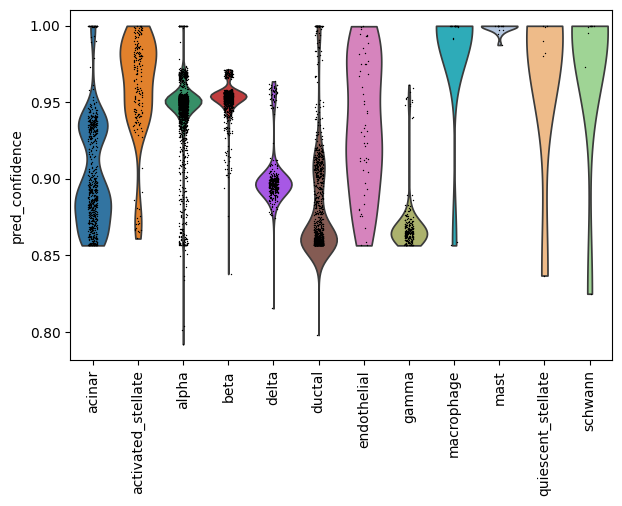

In [11]:
ax = sc.pl.violin(adata, keys="pred_confidence", groupby="pred_cell_type", rotation=90, show=False)
ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [12]:
print(adata.obs["pred_cell_type"].isna().sum())
# combine labels and unlabels
adata.obs["pred_cell_type"] = (
    adata.obs["pred_cell_type"].astype("string")
    .fillna(adata.obs["semi_cell_type"].astype("string"))
)

print(adata.obs["pred_cell_type"].isna().sum())

8569
0


In [13]:
methods = ["X_supbiot"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata, use_rep=method)
    sc.tl.umap(adata)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata, key_added=leiden_method, resolution=0.8)

## Visualize
Compare batch and Leiden structure across embeddings in UMAP panels.

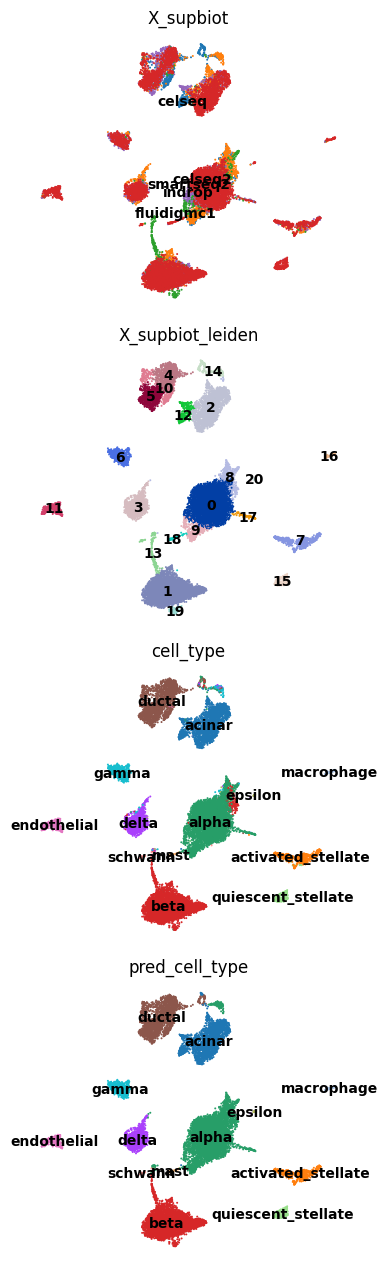

In [14]:
import matplotlib.pyplot as plt
import scanpy as sc

n_rows = 4
fig, axes = plt.subplots(
    n_rows,
    len(methods),
    figsize=(4 * len(methods), 3.2 * n_rows),
    squeeze=False
)

row_titles = ["batch", "leiden", "cell_type", "pred_cell_type"]

for col, method in enumerate(methods):
    basis = f"X_umap_{method}"          # or f"umap_{method}" if you store in obsm["X_umap_{method}"]
    leiden_key = f"{method}_leiden"

    # Row 0: batch
    sc.pl.embedding(
        adata,
        basis=basis,
        color="batch",
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,
        title=f"{method}"
    )

    # Row 1: leiden
    sc.pl.embedding(
        adata,
        basis=basis,
        color=leiden_key,
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,
        title=None
    )

    # Row 2: cell_type
    sc.pl.embedding(
        adata,
        basis=basis,
        color="cell_type",
        frameon=False,
        ax=axes[2, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,
        title=None
    )

    # Row 3: pred_cell_type
    sc.pl.embedding(
        adata,
        basis=basis,
        color="pred_cell_type",
        frameon=False,
        ax=axes[3, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,
        title=None
    )

# Optional: add row labels on the left-most column
for r, lab in enumerate(row_titles):
    axes[r, 0].set_ylabel(lab)

plt.tight_layout()
# fig.savefig("batch_and_annotations_per_embedding.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)

## Benchmark
fix the bug in the scib-metrics: change _graph_connectivity.py: <mask = labels == label> to <mask = (labels == label).to_numpy()>


In [15]:
bm = Benchmarker(
    adata, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_supbiot"],
    n_jobs=-1
    
)
bm.benchmark()

Embeddings: 100%|██████████| 2/2 [00:31<00:00, 15.86s/it]


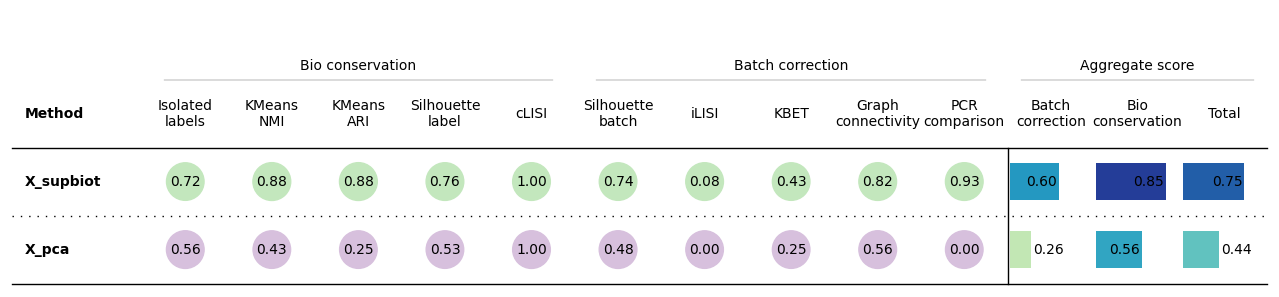

In [16]:
bm.plot_results_table(min_max_scale=False)